# Notebook 04 — Twitter-RoBERTa warm-start on Cyberbullying Kaggle

**Purpose.** Domain-adapt `cardiffnlp/twitter-roberta-base-2022-154m` on the Cyberbullying Kaggle dataset (47K tweets, 6 classes) as a pretext task. The encoder + LoRA adapters carry forward to NB05 (MMHS150K T1 fine-tune); **the classification head is discarded.**

**Inputs.** `data/cyberbullying_tweets.csv` (47,692 rows; columns `tweet_text`, `cyberbullying_type`).

**Outputs.**
- `models/roberta_pretrain/` — PEFT LoRA adapter (rank 16) + tokenizer + hparams.json + training_history.json. No head.
- `outputs/nb04_confusion_matrix.png` — test-set confusion matrix.
- `outputs/nb04_training_curves.png` — train/val loss + val macro-F1 per epoch.

**Design choices (locked in CLAUDE.md).** LoRA rank 16 on attention `query`+`value` (PEFT) — never full fine-tune. Focal CE (γ=2) with class weights from train distribution. fp16 throughout. Hashtags/mentions/URLs preserved in tokenizer input. Seeds=42.

In [1]:
import os, sys, json, random, gc, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from peft import LoraConfig, get_peft_model, TaskType

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')
if torch.cuda.is_available():
    print(f'gpu mem: {torch.cuda.get_device_properties(0).total_memory/1024**3:.2f} GB')

HPARAMS = dict(
    max_len=128,
    batch_size=16,
    epochs=3,
    lora_rank=16,
    lora_lr=1e-4,
    head_lr=1e-3,
    warmup_ratio=0.1,
    gamma=2.0,
    n_classes=6,
    weight_decay=0.01,
    model_name='cardiffnlp/twitter-roberta-base-2022-154m',
    seed=SEED,
)
for k, v in HPARAMS.items():
    print(f'  {k}: {v}')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_CSV = ROOT / 'data' / 'cyberbullying_tweets.csv'
OUT_DIR = ROOT / 'outputs'
MODEL_DIR = ROOT / 'models' / 'roberta_pretrain'
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print('ROOT:', ROOT)
print('CSV exists:', DATA_CSV.exists())

device: cuda | Tesla T4
gpu mem: 14.56 GB
  max_len: 128
  batch_size: 16
  epochs: 3
  lora_rank: 16
  lora_lr: 0.0001
  head_lr: 0.001
  warmup_ratio: 0.1
  gamma: 2.0
  n_classes: 6
  weight_decay: 0.01
  model_name: cardiffnlp/twitter-roberta-base-2022-154m
  seed: 42
ROOT: /teamspace/studios/this_studio/HateFusion
CSV exists: True


In [2]:
df = pd.read_csv(DATA_CSV)
print('raw shape:', df.shape)
print('nulls:', df.isna().sum().to_dict())

dupes = df.duplicated(subset=['tweet_text']).sum()
df = df.drop_duplicates(subset=['tweet_text']).reset_index(drop=True)
print(f'dropped {dupes} duplicate tweet_text rows')

LABELS = ['not_cyberbullying', 'religion', 'age', 'ethnicity', 'gender', 'other_cyberbullying']
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for l, i in label2id.items()}
df['label'] = df['cyberbullying_type'].map(label2id)

assert df['label'].isna().sum() == 0, 'unmapped label values present'
df['label'] = df['label'].astype(int)

print('after dedupe shape:', df.shape)
print('nulls:', df.isna().sum().to_dict())
print('class distribution:')
print(df['cyberbullying_type'].value_counts())

raw shape: (47692, 2)
nulls: {'tweet_text': 0, 'cyberbullying_type': 0}
dropped 1675 duplicate tweet_text rows
after dedupe shape: (46017, 3)
nulls: {'tweet_text': 0, 'cyberbullying_type': 0, 'label': 0}
class distribution:
cyberbullying_type
religion               7995
age                    7992
ethnicity              7952
not_cyberbullying      7937
gender                 7898
other_cyberbullying    6243
Name: count, dtype: int64


In [3]:
X = np.array(df['tweet_text'].tolist(), dtype=object)
y = np.array(df['label'].tolist(), dtype=np.int64)

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.05, stratify=y, random_state=SEED
)
val_frac_of_tv = 0.05 / 0.95
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=val_frac_of_tv, stratify=y_tv, random_state=SEED
)

print(f'train {len(X_train):>6} | val {len(X_val):>5} | test {len(X_test):>5}  (total {len(X_train)+len(X_val)+len(X_test)})')
for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    counts = pd.Series(yy).value_counts().sort_index()
    pretty = {id2label[i]: int(c) for i, c in counts.items()}
    print(f'  {name:5s} dist: {pretty}')

train  41415 | val  2301 | test  2301  (total 46017)
  train dist: {'not_cyberbullying': 7143, 'religion': 7195, 'age': 7193, 'ethnicity': 7157, 'gender': 7108, 'other_cyberbullying': 5619}
  val   dist: {'not_cyberbullying': 397, 'religion': 400, 'age': 399, 'ethnicity': 398, 'gender': 395, 'other_cyberbullying': 312}
  test  dist: {'not_cyberbullying': 397, 'religion': 400, 'age': 400, 'ethnicity': 397, 'gender': 395, 'other_cyberbullying': 312}


In [4]:
tokenizer = AutoTokenizer.from_pretrained(HPARAMS['model_name'])
print('tokenizer:', tokenizer.__class__.__name__, '| vocab:', tokenizer.vocab_size)

class CyberbullyDataset(Dataset):
    """Pre-tokenized at __init__ to save per-step CPU cost.
    Hashtags, mentions, URLs are kept as-is (CLAUDE.md §3 rule)."""

    def __init__(self, texts, labels, tok, max_len):
        enc = tok(list(texts), truncation=True, padding='max_length',
                  max_length=max_len, return_tensors='pt')
        self.input_ids = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.labels = torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return self.labels.size(0)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'label': self.labels[idx],
        }

train_ds = CyberbullyDataset(X_train, y_train, tokenizer, HPARAMS['max_len'])
val_ds = CyberbullyDataset(X_val, y_val, tokenizer, HPARAMS['max_len'])
test_ds = CyberbullyDataset(X_test, y_test, tokenizer, HPARAMS['max_len'])

train_loader = DataLoader(train_ds, batch_size=HPARAMS['batch_size'], shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=HPARAMS['batch_size'], shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=HPARAMS['batch_size'], shuffle=False,
                         num_workers=2, pin_memory=True)

print(f'datasets: train {len(train_ds)} | val {len(val_ds)} | test {len(test_ds)}')
print('sample (first 30 toks):', tokenizer.decode(train_ds[0]['input_ids'][:30]))

tokenizer: RobertaTokenizer | vocab: 50265


datasets: train 41415 | val 2301 | test 2301
sample (first 30 toks): <s>RT @Hari_Sethi: You know most people are intelligent enough to realise #BlameOneNotAll is just a reworking


In [5]:
class_weights_np = compute_class_weight('balanced', classes=np.arange(HPARAMS['n_classes']), y=y_train)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=device)
print('class weights (balanced):')
for i, w in enumerate(class_weights_np):
    print(f'  {id2label[i]:>22s}  {w:.4f}')

class FocalCE(nn.Module):
    """Multi-class focal cross-entropy with optional per-class weighting.
    Focal weight is (1-p_t)^gamma applied to the standard CE; gamma=2 per CLAUDE.md §12."""

    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, target):
        logp = F.log_softmax(logits, dim=-1)
        p = logp.exp()
        t_logp = logp.gather(1, target.unsqueeze(1)).squeeze(1)
        t_p = p.gather(1, target.unsqueeze(1)).squeeze(1)
        focal = (1.0 - t_p).pow(self.gamma) * (-t_logp)
        if self.weight is not None:
            focal = focal * self.weight.gather(0, target)
        return focal.mean()

criterion = FocalCE(gamma=HPARAMS['gamma'], weight=class_weights)
print(f'criterion ready: FocalCE(gamma={HPARAMS["gamma"]}, class-weighted)')

class weights (balanced):
       not_cyberbullying  0.9663
                religion  0.9593
                     age  0.9596
               ethnicity  0.9644
                  gender  0.9711
     other_cyberbullying  1.2284
criterion ready: FocalCE(gamma=2.0, class-weighted)


In [6]:
class RobertaClassifier(nn.Module):
    """Twitter-RoBERTa encoder + LoRA adapters + a fresh 6-class head.
    The head is discarded after this notebook; downstream notebooks attach their own."""

    def __init__(self, base_model_name: str, n_classes: int, lora_rank: int):
        super().__init__()
        backbone = AutoModel.from_pretrained(base_model_name)
        lora_cfg = LoraConfig(
            task_type=TaskType.FEATURE_EXTRACTION,
            r=lora_rank,
            lora_alpha=lora_rank * 2,
            lora_dropout=0.1,
            target_modules=['query', 'value'],
            bias='none',
        )
        self.encoder = get_peft_model(backbone, lora_cfg)
        hidden = backbone.config.hidden_size
        self.head = nn.Linear(hidden, n_classes)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0]
        return self.head(cls)

model = RobertaClassifier(HPARAMS['model_name'], HPARAMS['n_classes'], HPARAMS['lora_rank']).to(device)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'total params:     {total:,}')
print(f'trainable params: {trainable:,}  ({100*trainable/total:.3f}%)')
model.encoder.print_trainable_parameters()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


total params:     125,240,070
trainable params: 594,438  (0.475%)
trainable params: 589,824 || all params: 125,235,456 || trainable%: 0.4710


In [7]:
lora_params = [p for n, p in model.named_parameters() if 'lora_' in n and p.requires_grad]
head_params = [p for n, p in model.named_parameters() if n.startswith('head.') and p.requires_grad]
other = [n for n, p in model.named_parameters() if p.requires_grad and 'lora_' not in n and not n.startswith('head.')]
assert not other, f'unexpected trainable params outside LoRA/head: {other[:5]}'

print(f'lora trainable tensors: {len(lora_params)} | head: {len(head_params)}')

optimizer = torch.optim.AdamW(
    [
        {'params': lora_params, 'lr': HPARAMS['lora_lr']},
        {'params': head_params, 'lr': HPARAMS['head_lr']},
    ],
    weight_decay=HPARAMS['weight_decay'],
)

steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * HPARAMS['epochs']
warmup_steps = int(HPARAMS['warmup_ratio'] * total_steps)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
print(f'steps/epoch: {steps_per_epoch} | total steps: {total_steps} | warmup: {warmup_steps}')

lora trainable tensors: 48 | head: 2
steps/epoch: 2589 | total steps: 7767 | warmup: 776


In [8]:
scaler = torch.amp.GradScaler('cuda')
history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_macro_f1': []}

for epoch in range(1, HPARAMS['epochs'] + 1):
    model.train()
    t0 = time.time()
    running_loss, n_batches = 0.0, 0
    for batch in train_loader:
        ids = batch['input_ids'].to(device, non_blocking=True)
        mask = batch['attention_mask'].to(device, non_blocking=True)
        y = batch['label'].to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', dtype=torch.float16):
            logits = model(ids, mask)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        running_loss += loss.item()
        n_batches += 1
    train_loss = running_loss / max(n_batches, 1)

    model.eval()
    val_running, vpreds, vtrue = 0.0, [], []
    with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
        for batch in val_loader:
            ids = batch['input_ids'].to(device, non_blocking=True)
            mask = batch['attention_mask'].to(device, non_blocking=True)
            y = batch['label'].to(device, non_blocking=True)
            logits = model(ids, mask)
            val_running += criterion(logits, y).item()
            vpreds.append(logits.argmax(-1).cpu().numpy())
            vtrue.append(y.cpu().numpy())
    val_loss = val_running / max(len(val_loader), 1)
    vpreds = np.concatenate(vpreds)
    vtrue = np.concatenate(vtrue)
    val_f1 = f1_score(vtrue, vpreds, average='macro')
    elapsed = time.time() - t0

    print(f'[epoch {epoch}/{HPARAMS["epochs"]}] '
          f'train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  '
          f'val_macro_f1={val_f1:.4f}  ({elapsed:.1f}s)')
    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_macro_f1'].append(val_f1)
    torch.cuda.empty_cache()

[epoch 1/3] train_loss=0.3039  val_loss=0.1791  val_macro_f1=0.8285  (194.4s)


[epoch 2/3] train_loss=0.1550  val_loss=0.1479  val_macro_f1=0.8484  (201.9s)


[epoch 3/3] train_loss=0.1348  val_loss=0.1441  val_macro_f1=0.8516  (201.7s)


                     precision    recall  f1-score   support

  not_cyberbullying     0.7040    0.5693    0.6295       397
           religion     0.9466    0.9750    0.9606       400
                age     0.9723    0.9650    0.9686       400
          ethnicity     0.9846    0.9673    0.9759       397
             gender     0.8957    0.8911    0.8934       395
other_cyberbullying     0.6057    0.7532    0.6714       312

           accuracy                         0.8575      2301
          macro avg     0.8515    0.8535    0.8499      2301
       weighted avg     0.8608    0.8575    0.8568      2301


TEST macro-F1: 0.8499


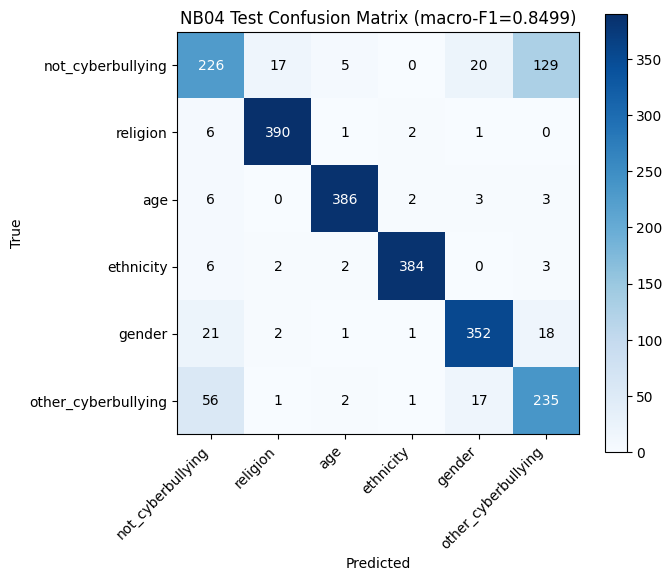

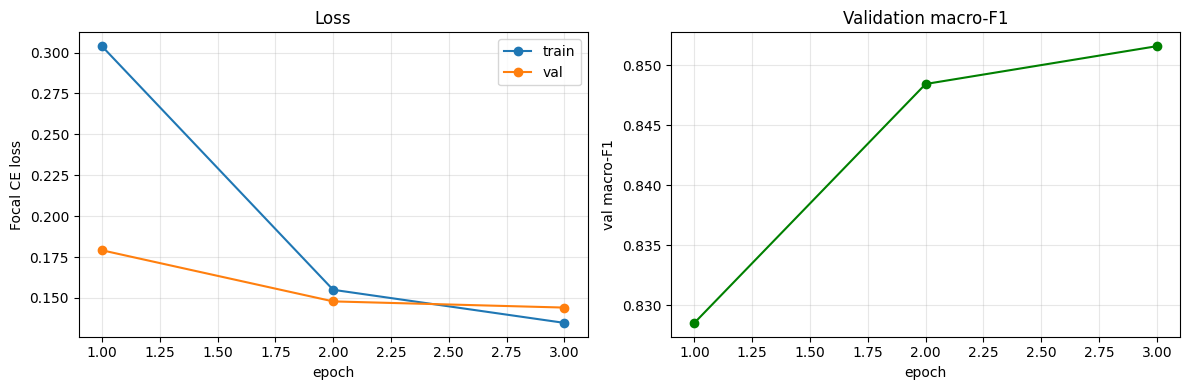

In [9]:
model.eval()
preds, trues = [], []
with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
    for batch in test_loader:
        ids = batch['input_ids'].to(device, non_blocking=True)
        mask = batch['attention_mask'].to(device, non_blocking=True)
        y = batch['label'].to(device, non_blocking=True)
        logits = model(ids, mask)
        preds.append(logits.argmax(-1).cpu().numpy())
        trues.append(y.cpu().numpy())
preds = np.concatenate(preds); trues = np.concatenate(trues)

print(classification_report(trues, preds, target_names=LABELS, digits=4))
test_macro_f1 = f1_score(trues, preds, average='macro')
print(f'\nTEST macro-F1: {test_macro_f1:.4f}')

cm = confusion_matrix(trues, preds)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(HPARAMS['n_classes']))
ax.set_yticks(range(HPARAMS['n_classes']))
ax.set_xticklabels(LABELS, rotation=45, ha='right')
ax.set_yticklabels(LABELS)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'NB04 Test Confusion Matrix (macro-F1={test_macro_f1:.4f})')
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb04_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['epoch'], history['train_loss'], '-o', label='train')
ax1.plot(history['epoch'], history['val_loss'], '-o', label='val')
ax1.set_xlabel('epoch'); ax1.set_ylabel('Focal CE loss')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(history['epoch'], history['val_macro_f1'], '-o', color='green')
ax2.set_xlabel('epoch'); ax2.set_ylabel('val macro-F1')
ax2.set_title('Validation macro-F1'); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb04_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
model.encoder.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

with open(MODEL_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
with open(MODEL_DIR / 'hparams.json', 'w') as f:
    json.dump(HPARAMS, f, indent=2)
with open(MODEL_DIR / 'labels.json', 'w') as f:
    json.dump({'label2id': label2id, 'id2label': id2label,
               'note': 'multi-class head trained here is intentionally NOT saved'}, f, indent=2)

print('Saved LoRA adapter + tokenizer to:', MODEL_DIR)
for p in sorted(MODEL_DIR.iterdir()):
    if p.is_file():
        size = p.stat().st_size
        unit = 'KB' if size < 1024**2 else 'MB'
        scale = 1024 if unit == 'KB' else 1024**2
        print(f'  {p.name:>40s}  {size/scale:>8.2f} {unit}')

print('\nNB04 complete. Head intentionally discarded — NB05 attaches a fresh T1 binary-hate head on top of these LoRA-adapted encoder weights.')

Saved LoRA adapter + tokenizer to: /teamspace/studios/this_studio/HateFusion/models/roberta_pretrain
                                 README.md      5.08 KB
                       adapter_config.json      1.02 KB
                 adapter_model.safetensors      2.26 MB
                              hparams.json      0.26 KB
                               labels.json      0.37 KB
                            tokenizer.json      3.39 MB
                     tokenizer_config.json      0.48 KB
                     training_history.json      0.32 KB

NB04 complete. Head intentionally discarded — NB05 attaches a fresh T1 binary-hate head on top of these LoRA-adapted encoder weights.
